## Master Agent testing:
### The Master Agent will process the user input to determine which agent to call given a list of questions generated by ChatGPT and humanly curated.
The questions are 50 questions designed to trigger the different agents in the system. 
The questions are stored in a text file, with each question on a new line.

In [3]:
import os
import pandas as pd

from AgentsClass import MasterAgent
from AgentsClass import MemoryMaster
from AgentsClass import LinkedInConnector
from AgentsClass import LinkedInSearcher
from AgentsClass import CompanySearcher
from AgentsClass import NewsSearcher
from AgentsClass import ChatBot

# vLLM API endpoint
API_URL = "http://localhost:8000/v1/completions"

AGENTS_NAMES =  {
                "LinkedIn Connector": "Specific for crafting messages used in LinkedIn connections",
                "LinkedIn Searcher": "Expert in getting information of a person's LinkedIn",
                "Company Searcher": "Expert in getting precise and audited information of a company from the internet",
                "News Searcher": "Expert in getting the latest news from the internet that might be relevant to the user",
                "Chat Bot": "Handles general questions when other agents can't. Perfect for small talk and general questions."
                }

AGENT_REGISTRY = {
                  "LinkedIn Connector": LinkedInConnector(),
                  "LinkedIn Searcher": LinkedInSearcher(),
                  "Company Searcher": CompanySearcher(),
                  "News Searcher": NewsSearcher(),
                  "Chat Bot": ChatBot()
                  }


In [3]:
# Directory containing the text files
directory = './tests/questions/'

questions_files = os.listdir(directory)

Agent_Master = MasterAgent(AGENTS_NAMES, API_URL)

# Read the questions from the text files
questions = []
for file in questions_files:
    # Initialize an empty DataFrame
    df = pd.DataFrame(columns=['Question', 'Response 1', 'Response 2', 'Response 3', 'Response 4', 'Response 5'])
    # Read the text file
    with open(directory + file, 'r') as f:
        lines = f.readlines()

    questions = [line.strip() for line in lines]

    for i, question in enumerate(questions):
        response = Agent_Master.process(question, n_answer=5,best_of_answer=5)
        df.loc[i] = [question] + response
        
    # Save the responses to a CSV file
    df.to_csv(f'./tests/{file[:-4]}.csv', index=False)
    
    print(f"Responses for {file} saved to CSV file.")


Responses for linkedin connector.txt saved to CSV file.
Responses for chatbot.txt saved to CSV file.
Responses for company.txt saved to CSV file.
Responses for news.txt saved to CSV file.
Responses for linkedin searcher.txt saved to CSV file.


In [4]:
# An interesting insight could come from shuffling the questions and sending them back to ChatGPT, to compare the responses with this model's.
# This was not used because I didn't have time to implement it nor a key to call the ChatGPT API.
import random

def shuffle_txt_files(folder_path, output_file):
    all_lines = []

    # Iterate over all text files in the folder
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):  # Process only .txt files
            file_path = os.path.join(folder_path, filename)
            with open(file_path, "r", encoding="utf-8") as file:
                all_lines.extend(file.read().splitlines())  # Read lines and remove newlines

    # Shuffle all lines
    random.shuffle(all_lines)

    # Write to a new file
    with open(output_file, "w", encoding="utf-8") as file:
        file.write("\n".join(all_lines))

    print(f"Shuffled lines saved to {output_file}")

# Example usage
folder_path = "./tests/questions/"  # Replace with your folder path
output_file = "shuffled_output.txt"
shuffle_txt_files(folder_path, output_file)


Shuffled lines saved to shuffled_output.txt


In [23]:
test_folder = './tests/'
test_files = []

test_files = [f for f in os.listdir(test_folder) if os.path.isfile(os.path.join(test_folder, f))]
test_files.pop(3) # Remove the overlap questions file
print(test_files)
test_files_names = ['Linkedin Connector', 'Company Searcher', 'Chat Bot', 'News Searcher', 'Linkedin Searcher']

['linkedin connector.csv', 'company.csv', 'chatbot.csv', 'news.csv', 'linkedin searcher.csv']


In [18]:
# Add the expected response from the question
df = pd.DataFrame()
for i, file in enumerate(test_files):
    temp_df = pd.read_csv(test_folder + file)
    # temp_df['file_name'] = file[:-4]
    temp_df['Expected Response'] = test_files_names[i]
    if file[:-4] == 'overlap questions':
        pass
    else:
        df = pd.concat([df, temp_df], ignore_index=True)

In [19]:
# get questions that had unique responses
df_unique_responses = df[df.loc[:, "Response 1":"Response 5"].nunique(axis=1) == 1]

In [20]:
def count_correct_responses(row):
    expected_lower = row["Expected Response"].lower()  # Convert expected response to lowercase
    return sum(row[f"Response {i+1}"].lower() == expected_lower for i in range(5))

# Apply function to count correct answers
df["Correct Answers"] = df.apply(count_correct_responses, axis=1)

percentage_consistent = (df.iloc[:, 1:6].nunique(axis=1) == 1).mean() * 100
print(f'% of consistent responses: {percentage_consistent:.2f}%')
consistent_correct = df[(df.iloc[:, 1:6].nunique(axis=1) == 1) & (df["Correct Answers"] == 5)].shape[0]
percentage_consistent_correct = (consistent_correct / len(df)) * 100
print(f'% of consistent and correct responses: {percentage_consistent_correct:.2f}%')

% of consistent responses: 43.60%
% of consistent and correct responses: 22.00%


In [21]:
# Make it case-insensitivity (Linkedin =/= LinkedIn ... commum problem)
response_cols = [col for col in df.columns if col.startswith("Response")]
df[response_cols] = df[response_cols].apply(lambda x: x.str.lower())
df["Expected Response"] = df["Expected Response"].str.lower()

# Count correct answers (case-insensitive)
df["Correct Answers"] = df.apply(lambda row: sum(row[col] == row["Expected Response"] for col in response_cols), axis=1)

# Determine the most common response (case-insensitive)
df["Given Answer"] = df[response_cols].mode(axis=1).iloc[:, 0]  # Select the first mode in case of ties

# Create the new table with relevant columns
new_df = df[["Question", "Correct Answers", "Expected Response", "Given Answer"]]

In [22]:
# Non Sense answers

test_files_names_lower = [name.lower() for name in test_files_names]  # Convert to lowercase

# Filter the DataFrame to keep only rows where the Given Answer is in the list
valid_df = new_df[new_df["Given Answer"].isin(test_files_names_lower)]
invalid_df = new_df[~new_df["Given Answer"].isin(test_files_names_lower)]

invalid_df.head()
print(f'% of nonsense responses: {len(invalid_df) / len(new_df) * 100:.2f}%')

% of nonsense responses: 35.20%


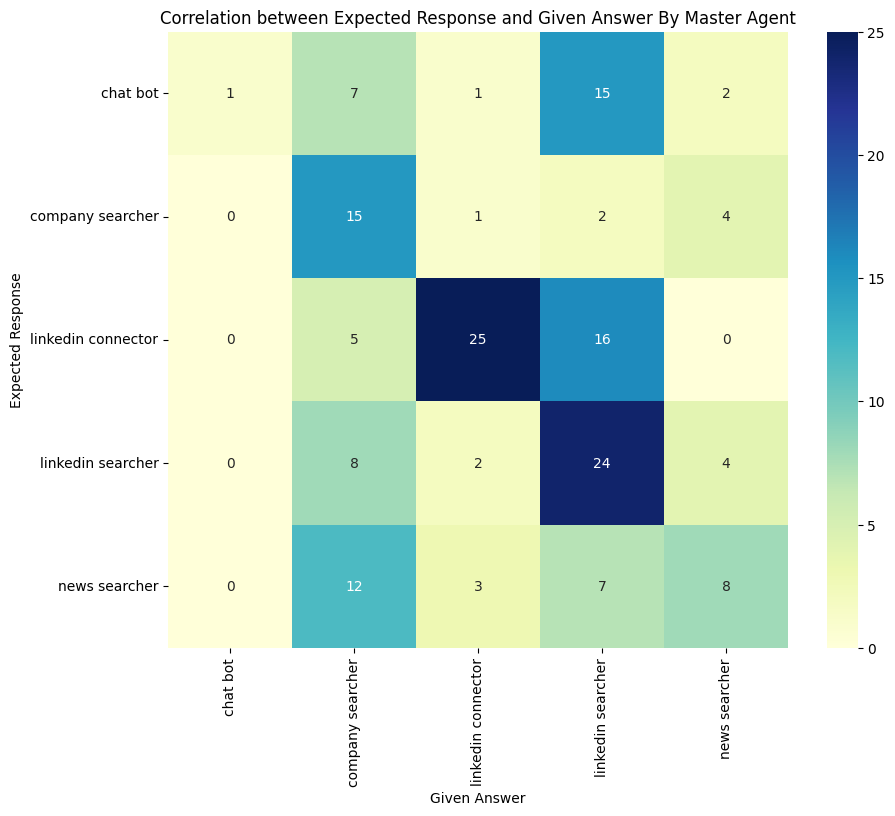

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_table = pd.crosstab(valid_df["Expected Response"], valid_df["Given Answer"])

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_table, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Correlation between Expected Response and Given Answer By Master Agent")
plt.xlabel("Given Answer")
plt.ylabel("Expected Response")
plt.show()